In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm
import scipy 

from tqdm import tqdm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize
import scipy.stats as stats

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11
from DRP_vel_map_functions import model_vel_map

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [6]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/gqp_0226/'
# plot_dir_HI = plot_dir + '/HI_spirals/'

In [7]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [8]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [9]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


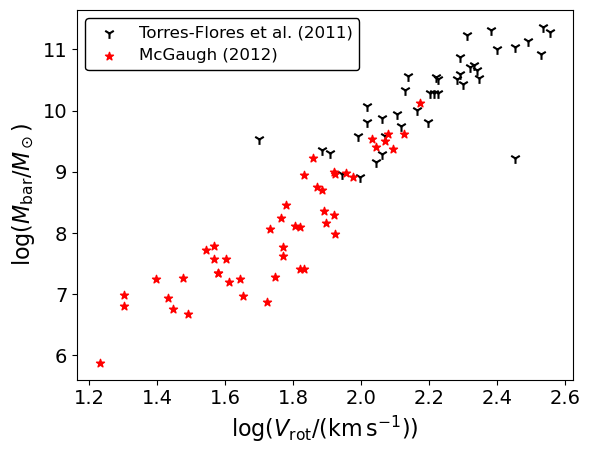

In [101]:
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'], marker='1', color='k', label='Torres-Flores et al. (2011)', s=60)
plt.scatter(np.log10(mcg['V_f']), mcg['Mstar'], marker='*', label='McGaugh (2012)', color='r')
plt.xlabel(r'$\log(V_{\rm rot}/(\rm km\, s^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm bar}/M_\odot)$', fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize='large', framealpha=1, facecolor='none', edgecolor='k')

plt.savefig(plot_dir + 'btfr_tf_mcg.png', transparent=False, bbox_inches='tight')

## velocity fields

In [47]:
test_gal = '8997-9102'

In [91]:
# pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
dap_maps = extract_data(VEL_FOLDER, test_gal, ['star_sigma', 'flux', 'Ha'])

idx = master_table_dict[test_gal]
# sMass = pipe3d_maps['sMass_density']
# sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]


v_sys = master_table['v_sys'][idx]
# i_angle = master_table['ba'][idx]

q0=0.2
cosi2 = (ba**2 - q0**2)/(1 - q0**2)

i_angle = np.arccos(np.sqrt(cosi2))

i_center = master_table['x0'][idx]
j_center = master_table['y0'][idx]
phi = master_table['phi'][idx]
v_max = master_table['v_max'][idx]
r_turn = master_table['r_turn'][idx]
alpha = master_table['alpha'][idx]

masked_ha = ma.array(dap_maps['Ha_vel'], mask=dap_maps['Ha_vel_mask'])

H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
G = 4.30091E-3 # Gravitation constant in units of (km/s)^2 pc/Msun

q0 = 0.2

MANGA_FIBER_DIAMETER = 2*(1/60)*(1/60)*(np.pi/180) # angular fiber diameter (2") in radians
MANGA_SPAXEL_SIZE = 0.5*(1/60)*(1/60)*(np.pi/180)  # spaxel size (0.5") in radians

dist_to_galaxy_Mpc = c*z/H_0
dist_to_galaxy_kpc = dist_to_galaxy_Mpc*1000

pix_scale_factor = dist_to_galaxy_kpc*np.tan(MANGA_SPAXEL_SIZE)

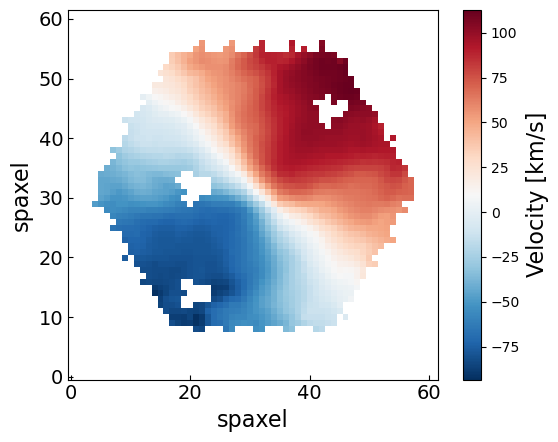

In [102]:
plt.imshow(masked_ha, cmap='RdBu_r', origin='lower')
plt.tick_params(labelsize=14, direction='in')
cbar = plt.colorbar()
cbar.set_label(label='Velocity [km/s]', size=16, )

plt.xlabel('spaxel', fontsize=16)
plt.ylabel('spaxel', fontsize=16)
plt.savefig(plot_dir + 'ha_vel_data.png', bbox_inches='tight')

In [89]:
model_vel_map?

Signature: model_vel_map(params, map_shape, scale, fit_function)
Docstring:
Create a model velocity map of shape map_shape based on the values in params


PARAMETERS

params : list
    List of fit parameters

map_shape : tuple
    Shape of velocity map array

scale : float
    Pixel scale (to convert from pixels to kpc)

fit_function : string
    Determines which function to use for the velocity.  Options are 'BB' and
    'tanh'.


RETURNS

vel_map : numpy array of shape map_shape
    Model velocity map array
File:      ~/Documents/Github/RotationCurves/spirals/DRP_vel_map_functions.py
Type:      function

In [97]:
ha_model = model_vel_map([v_sys, i_angle, i_center, j_center, phi+90, v_max, r_turn, alpha],
                         dap_maps['Ha_vel'].shape,
                         pix_scale_factor,
                         'BB')
                         

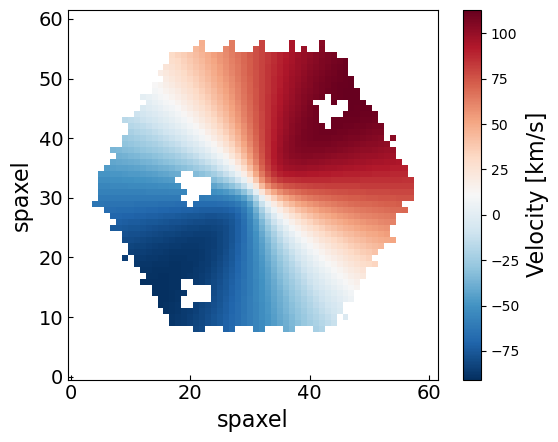

In [103]:
plt.imshow(ma.array(ha_model, mask=dap_maps['Ha_vel_mask']), cmap='RdBu_r', origin='lower')
plt.tick_params(labelsize=14, direction='in')
cbar = plt.colorbar()
cbar.set_label(label='Velocity [km/s]', size=16, )

plt.xlabel('spaxel', fontsize=16)
plt.ylabel('spaxel', fontsize=16)
plt.savefig(plot_dir + 'ha_vel_model.png', bbox_inches='tight')